# GSE182270 初步分析
结肠组织样本，选取其中8个样本进行分析（排除一个UC正常部位）  
4UC，4HC
- UC1-UC4
- HC1-HC4

In [ ]:
import scanpy as sc
import omicverse as ov
ov.plot_set()
ov.settings.cpu_gpu_mixed_init()

/home/future/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


🔬 Starting plot initialization...
🧬 Detecting CUDA devices…
✅ [GPU 0] NVIDIA GeForce RTX 5060 Ti
    • Total memory: 15.9 GB
    • Compute capability: 12.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.7   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [3]:
!pwd

/home/future/UC_Treg_Project/notebooks/1_preprocessing


## 读取MTX类型数据

In [4]:
import os

data_dirs = ["/mnt/e/UC/scRNA-seq_RAW/1_GSE182270"]
adatas = []

for data_dir in data_dirs:
    for sample in sorted(os.listdir(data_dir)):
        path = os.path.join(data_dir, sample)
        if not os.path.isdir(path):
            continue

        ad = sc.read_10x_mtx(path, var_names='gene_symbols', cache=False)
        sc.pp.filter_cells(ad, min_genes=200)
        sc.pp.filter_genes(ad, min_cells=3)

        ad.obs['GSM_id'] = sample
        ad.obs_names = [f"{sample}_{x}" for x in ad.obs_names] 
        adatas.append(ad)     

adata = sc.concat(adatas, merge='same')

--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
filtered out 15168 genes that are detected in less than 3 cells
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
filtered out 1 cells that have less than 200 genes expressed
filtered out 15734 genes that are detected in less than 3 cells
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
filtered out 2 cells that have less than 200 genes expressed
filtered out 15696 genes that are detected in less than 3 cells
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
filtered out 1 cells that have less than 200 genes expressed
filtered out 15805 genes that are detected in less than 3 cells
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache fi

In [5]:
adata

AnnData object with n_obs × n_vars = 33365 × 15077
    obs: 'n_genes', 'GSM_id'
    var: 'gene_ids', 'feature_types'

In [6]:
adata.obs['GSM_id'].value_counts()

GSM_id
GSM5525963_UC4    5878
GSM5525957_UC3    5350
GSM5525962_HC3    4944
GSM5525955_UC1    4765
GSM5525959_HC4    4063
GSM5525960_HC1    3020
GSM5525961_HC2    2959
GSM5525956_UC2    2386
Name: count, dtype: int64

In [7]:
adata.obs['GSM'] = adata.obs['GSM_id'].str.split("_").str[0]  
adata.obs['id']  = adata.obs['GSM_id'].str.split("_").str[1]  

## 预处理步骤
- QC: mito<0.2, UMI>500, genes>250, 去除双细胞
- HVG: Pearson方法，2000个
- PCA: 50个PCs
- neighbors: 最邻近数15，使用前50PCs
- leiden: resolution0.7

In [8]:
# QC
adata=ov.pp.qc(adata,
               tresh={'mito_perc': 0.2, 'nUMIs': 500, 'detected_genes': 250},
               doublets_method='scrublet',
               batch_key=None)

# HVG
adata=ov.pp.preprocess(adata,
                       mode='shiftlog|pearson',
                       n_HVGs=2000,
                       target_sum=50*1e4)

adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]

# PCA
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)

# Embedding the neighborhood graph
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='scaled|original|X_pca')

# UMAP
ov.pp.umap(adata)

# Clustering
ov.pp.leiden(adata,resolution=0.7)

⚙️ Using CPU/GPU mixed mode for QC...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA GeForce RTX 5060 Ti
    ||||-------------------------- 2672/16311 MiB (16.4%)

🔍 Quality Control Analysis (CPU-GPU Mixed):
   Dataset shape: 33,365 cells × 15,077 genes
   QC mode: seurat
   Doublet detection: scrublet
   Mitochondrial genes: MT-

📊 Step 1: Calculating QC Metrics
   Mitochondrial genes (prefix 'MT-'): 13 found
   ✓ QC metrics calculated:
     • Mean nUMIs: 7133 (range: 489-115012)
     • Mean genes: 1257 (range: 198-8501)
     • Mean mitochondrial %: 7.5% (max: 93.5%)

🔧 Step 2: Quality Filtering (SEURAT)
   Thresholds: mito≤0.2, nUMIs≥500, genes≥250
   📊 Seurat Filter Results:
     • nUMIs filter (≥500): 6 cells failed (0.0%)
     • Genes filter (≥250): 180 cells failed (0.5%)
     • Mitochondrial filter (≤0.2): 2,374 cells failed (7.1%)
   ✓ Combined QC filters: 2,468 cells removed (7.4%)

🎯 Step 3: Final Filtering
   Parameters: min_genes=200, min_cells=3
   Ratios: max_genes_ratio=1,

In [9]:
adata

AnnData object with n_obs × n_vars = 30896 × 2000
    obs: 'n_genes', 'GSM_id', 'GSM', 'id', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet', 'leiden'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_features'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU', 'log1p', 'hvg', 'pca', 'scaled|original|pca_var_ratios', 'scaled|original|cum_sum_eigenvalues', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'scaled|original|X_pca', 'X_umap'
    varm: 'PCs', 'scaled|original|pca_loadings'
    layers: 'counts', 'scaled'
    obsp: 'distances', 'connectivities'

In [23]:
adata.obs['id'].value_counts()

id
UC4    5404
UC3    5320
UC1    4755
HC4    4036
HC3    3098
HC1    2995
HC2    2941
UC2    2347
Name: count, dtype: int64

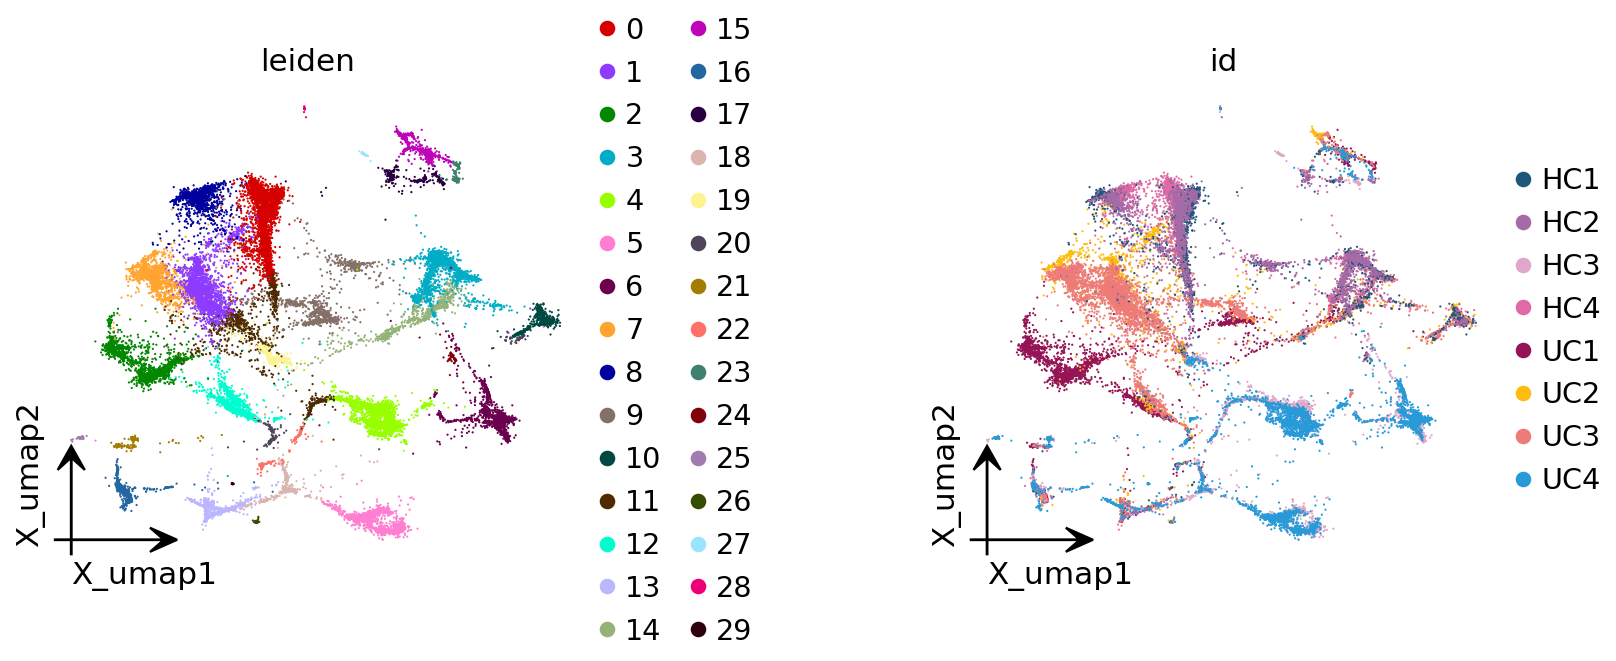

In [10]:
# 可视化查看聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'id'],
                frameon='small',
                wspace=0.5)

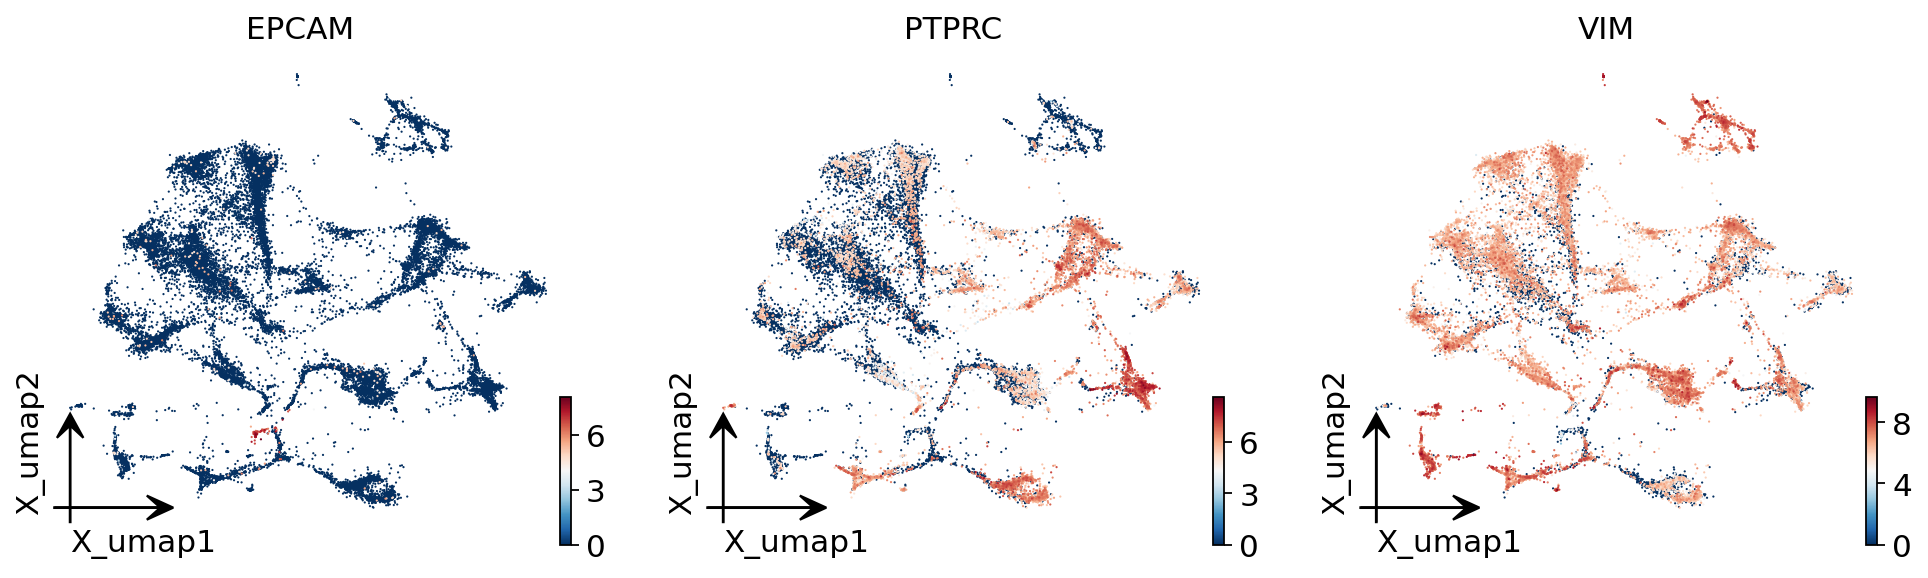

In [18]:
# 粗略查看上皮、免疫、基质细胞
ov.pl.embedding(adata,
                basis='X_umap',
                color=['EPCAM', 'PTPRC', 'VIM'],
                frameon='small')

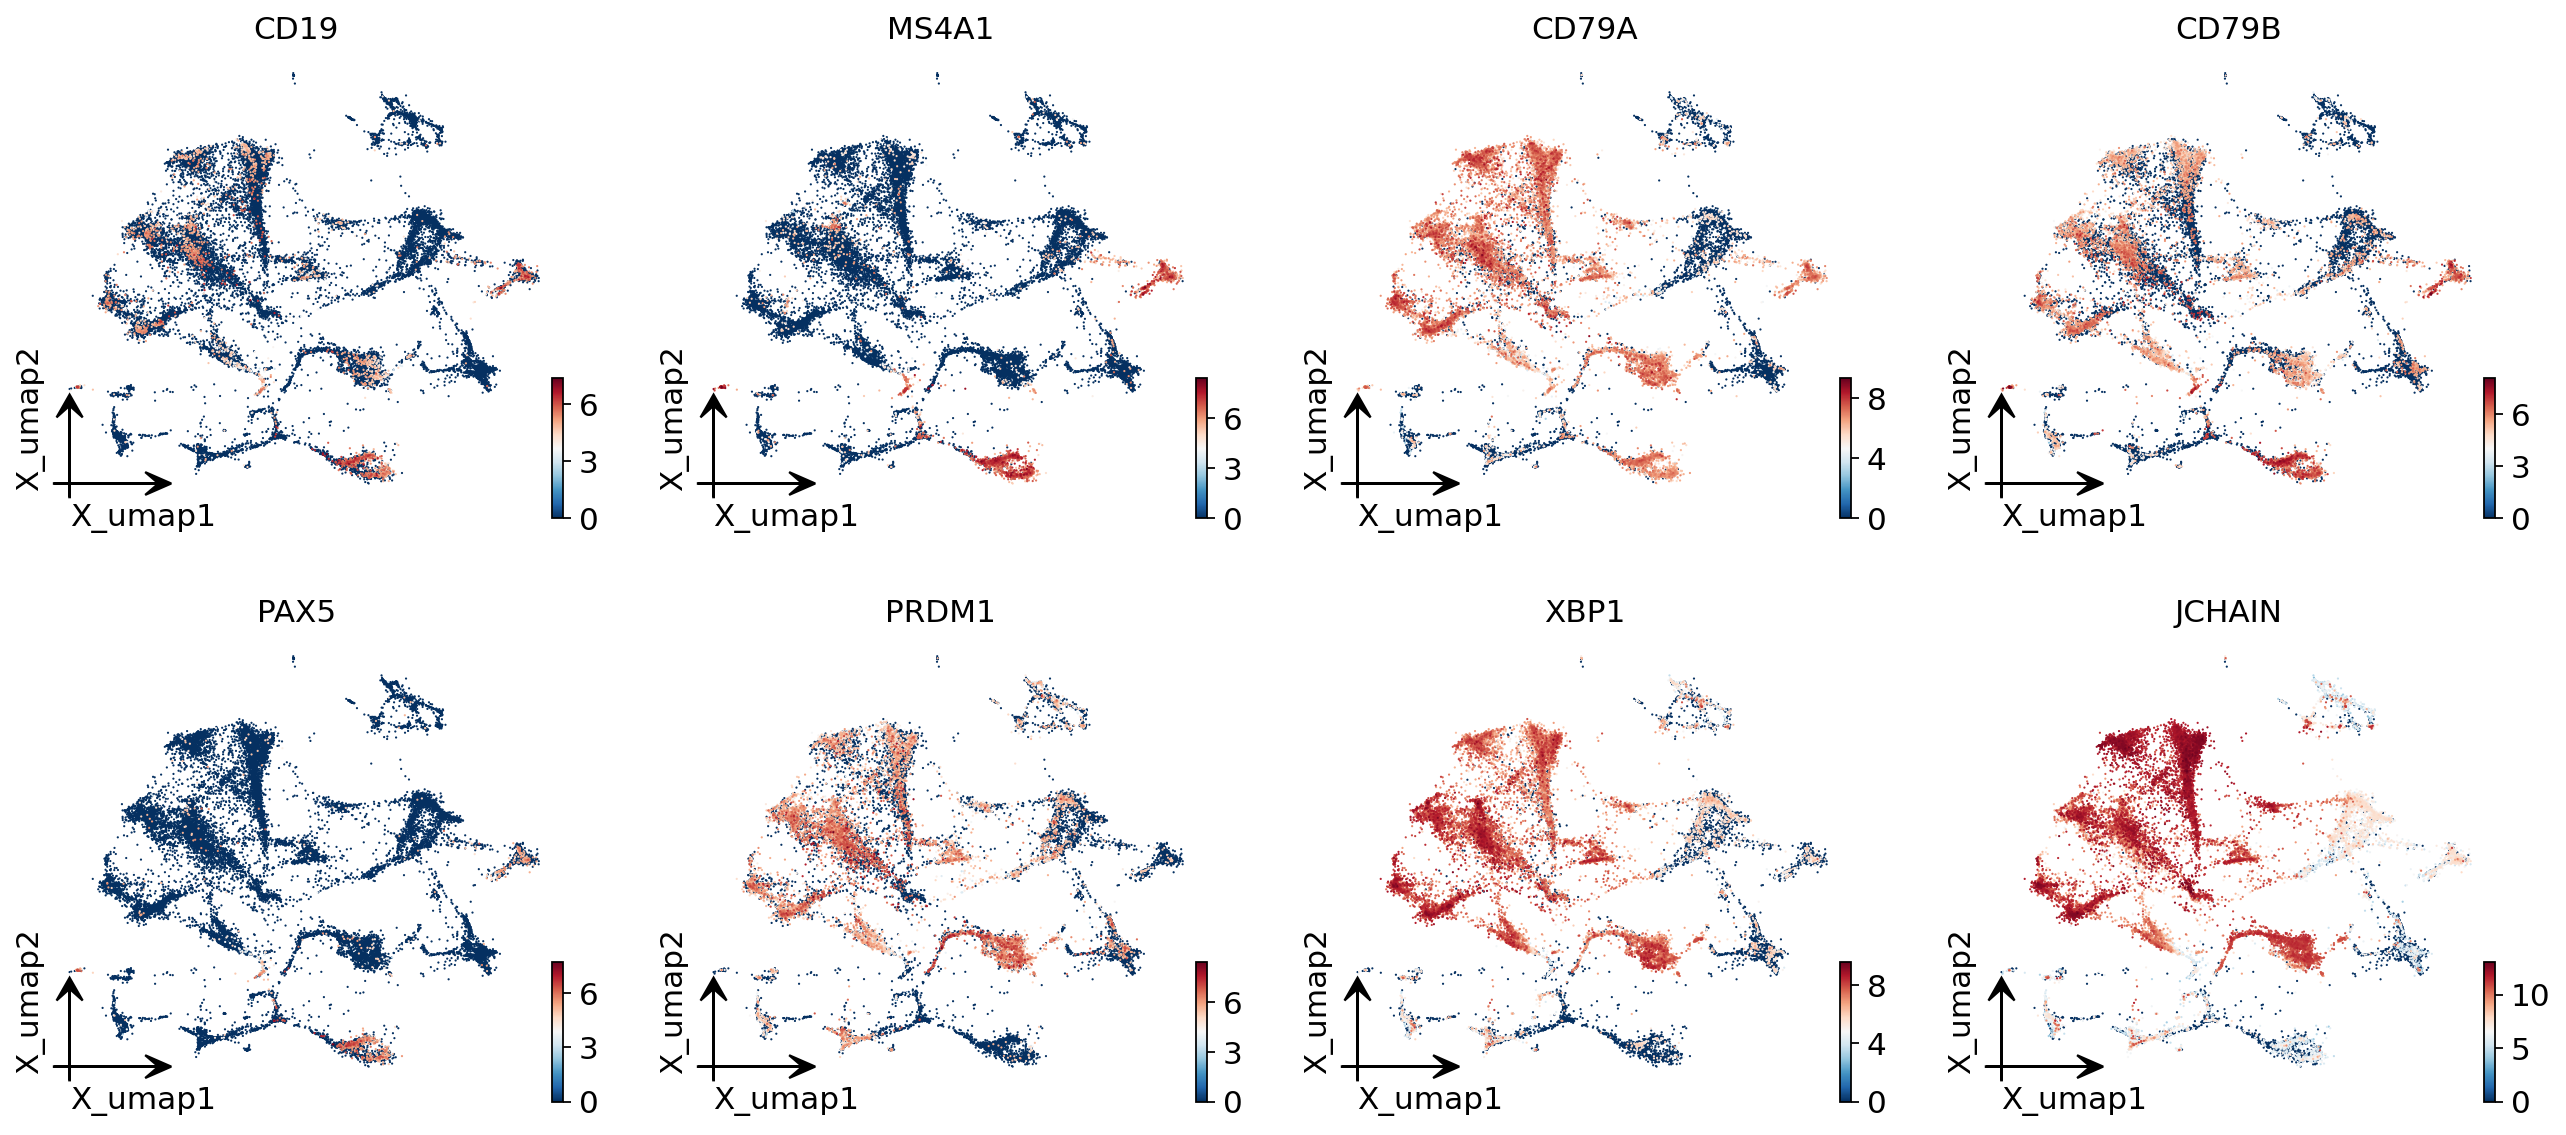

In [21]:
# 查看B细胞和浆细胞
ov.pl.embedding(adata,
                basis='X_umap',
                color=['CD19', 'MS4A1', 'CD79A', 'CD79B', 'PAX5', 'PRDM1', 'XBP1', 'JCHAIN'],
                frameon='small')

## GPT自动注释

In [11]:
# 获取每个细胞群的基因
all_markers = ov.single.get_celltype_marker(adata,
                                            clustertype='leiden',
                                            rank=True,
                                            key='rank_genes_groups',
                                            foldchange=1,
                                            topgenenumber=10)
all_markers

...get cell type marker
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:09)


{'0': ['TNFRSF17',
  'CIRBP',
  'IGHA2',
  'IGKC',
  'JUN',
  'JCHAIN',
  'IGHA1',
  'FOSB',
  'AL928768.3',
  'TMEM258'],
 '1': ['PRDX4',
  'IGHG4',
  'IGHG3',
  'IGHG1',
  'IGKC',
  'MZB1',
  'ISG20',
  'IGHG2',
  'HERPUD1',
  'XBP1'],
 '10': ['HLA-DPB1',
  'RPL31',
  'HLA-DRB1',
  'CD37',
  'HLA-DQB1',
  'HLA-DQA1',
  'HLA-DRA',
  'CD74',
  'HLA-DPA1',
  'MS4A1'],
 '11': ['FKBP2',
  'NEAT1',
  'SSR4',
  'MT-ND3',
  'IGKC',
  'IGHA2',
  'IGHA1',
  'JCHAIN',
  'HERPUD1',
  'ANKRD28'],
 '12': ['TUBA1B',
  'HMGB2',
  'STMN1',
  'H2AFZ',
  'HMGB1',
  'CHCHD2',
  'GAPDH',
  'KIAA0101',
  'SUB1',
  'MTDH'],
 '13': ['CST3',
  'HLA-DPB1',
  'TYROBP',
  'LYZ',
  'AIF1',
  'HLA-DRB1',
  'FCER1G',
  'HLA-DRA',
  'CD74',
  'HLA-DPA1'],
 '14': ['ACTG1',
  'CD2',
  'PFN1',
  'GAPDH',
  'TRAC',
  'IL32',
  'CD3D',
  'ACTB',
  'TMSB4X',
  'COTL1'],
 '15': ['CALD1',
  'RARRES2',
  'IFITM3',
  'COL1A2',
  'TIMP1',
  'LUM',
  'TPM2',
  'DCN',
  'COL3A1',
  'C1S'],
 '16': ['CRIP2',
  'RAMP2',
  'PLVAP',

In [22]:
os.environ['AGI_API_KEY'] = 'sk-ff0dc715f640466393e6aa71c9da6848'
result = ov.single.gptcelltype(all_markers,
                               tissuename='colon',
                               speciename='human',
                               model='qwen-plus',
                               provider='qwen',
                               topgenenumber=10)
result

Note: AGI API key found: returning the cell type annotations.
Note: It is always recommended to check the results returned by GPT-4 in case of AI hallucination, before going to downstream analysis.


{'0': 'Plasma cells',
 '1': 'Plasma cells',
 '10': 'B cells',
 '11': 'Plasma cells',
 '12': 'Proliferating cells',
 '13': 'Myeloid cells',
 '14': 'T cells',
 '15': 'Fibroblasts',
 '16': 'Endothelial cells',
 '17': 'Fibroblasts',
 '18': 'Mixed (myeloid, endothelial, fibroblast)',
 '19': 'Plasma cells',
 '2': 'Plasma cells',
 '20': 'B cells',
 '21': 'Smooth muscle cells',
 '22': 'Epithelial cells',
 '23': 'Smooth muscle cells',
 '24': 'T cells',
 '25': 'B cells',
 '26': 'Dendritic cells',
 '27': 'Pericytes',
 '28': 'Epithelial cells',
 '29': 'Plasma cells',
 '3': 'Plasma cells',
 '4': 'Macrophages',
 '5': 'Fibroblasts',
 '6': 'Dendritic cells',
 '7': 'T cells',
 '8': 'B cells',
 '9': 'Plasma cells'}

In [24]:
# 添加识别结果到obs
adata.obs['gpt_celltype'] = adata.obs['leiden'].map(result).astype('category')

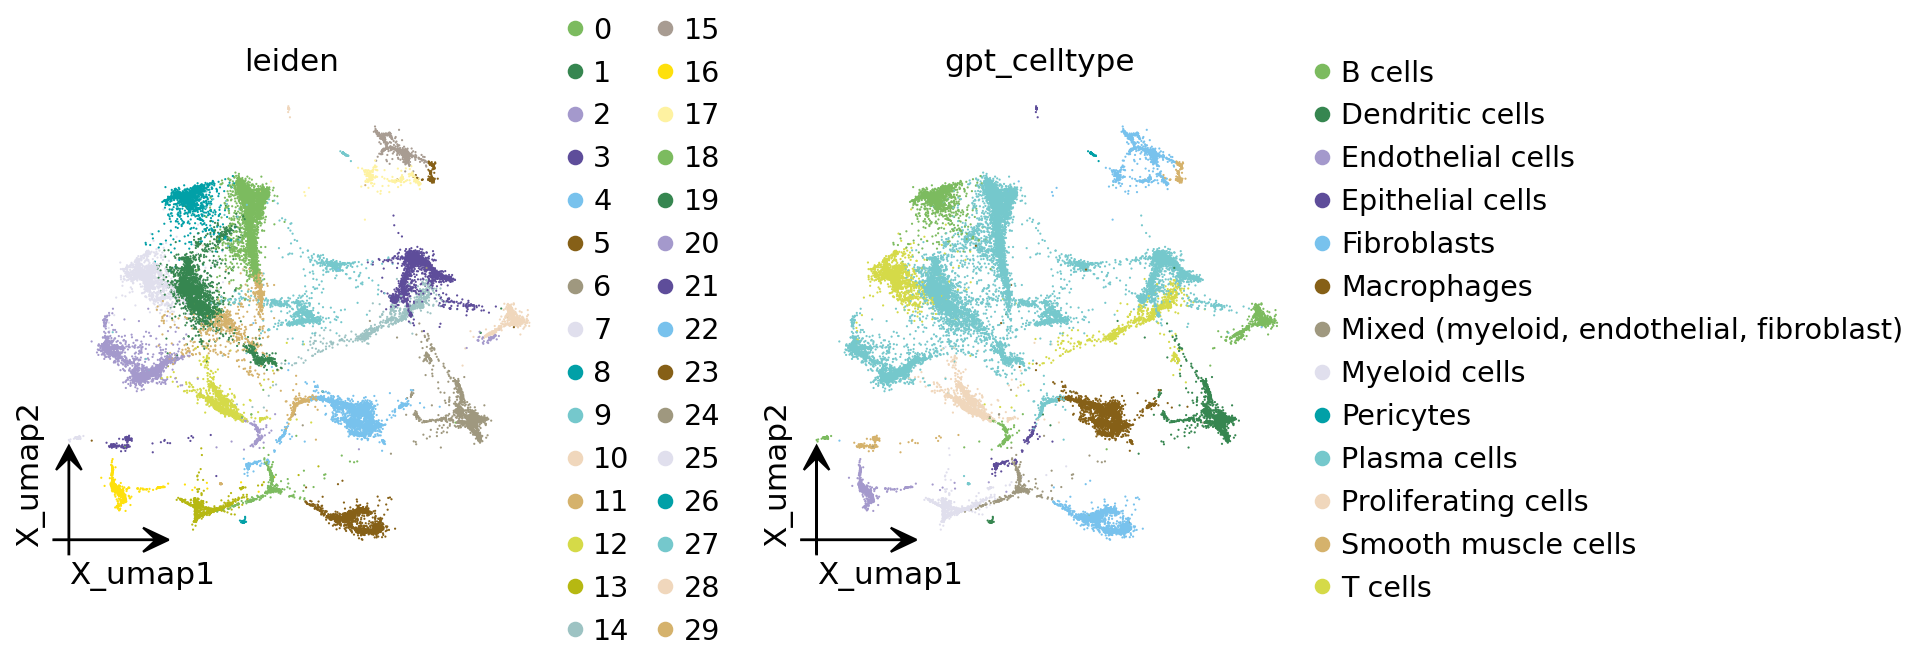

In [25]:
# 可视化查看结果
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'gpt_celltype'],
                # legend_loc='on data',
                frameon='small',
                legend_fontoutline=0.5,
                palette=ov.utils.palette()[10:],
                wspace=0.3)

# 总结
疑问：
- 上皮细胞很少
- 浆细胞众多